#https://www.dspguide.com/pdfbook.htm
konvoluce -> odezva filteru (response)
Lineární filtr -> impulzní, krobová, frekvenční y(t) = x(t)*h(t)
                                                odezva=signal*charakteristika
impulzní charaktertiska h^(i)t   
        x(t)->x(t)&h(t)->y(t)
        kroková odezva
        h^(k)t x(t) -> x(t)*h^(k)t      y(t)    f
        frekvenční
    
x(t) -> y(t)  ->  y'(t) -> y"(t)
    TR              TR'      TR"

FIR, IIR
konvoluční filtry - FIR (časy) 
    impulzní odezva -> FT(y^i) - y^f, y^(k)t = integ (ekg)
 rekurzivní filtry - IIR
    frekvenční fdoména - šum

rise time(mez casu ve kter to stoupa), overshoot(přes mez), linear phase(linearity)
frekvenční - low pass, high pass, burd pass, band reget, roll-off, riple
kroková

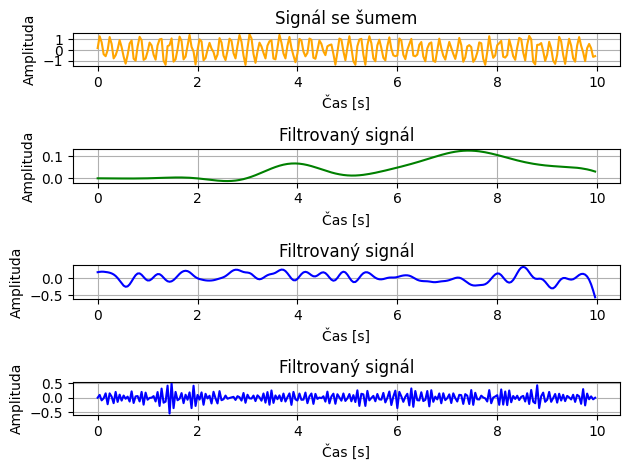

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, firwin, butter, filtfilt, freqz

f_vz = 500; amp = 1.0; freq = 5; T = 1/freq; numT = 50; Tmax = numT*T; n_length = int(numT*freq)
t = np.linspace(0,Tmax,n_length,endpoint=False) #mi pocatek ite periody signalu

signal = np.sin(2*np.pi*freq*t)
#sum = np.random.normal(0,1,f_vz) # li pocet ltého vzorku v rámci periody
amp = 1 #měníme amplitudu v signálu
sum = np.array(amp*np.random.rand(t.size)-0.5)
sum_v_signalu = signal + sum

#FIR  filtr
cutoff = 10 #hraniční frekvence
numtaps = 200#poet koeficientů filtru
fir_coefs = firwin(numtaps, cutoff, fs=f_vz, pass_zero="lowpass")

filtered_signal_fir = lfilter(fir_coefs,1.0,sum_v_signalu) #fitrovaný podle FIR

cutoff = 50
order = 4 #řád filtru
b,a = butter(order,cutoff/(f_vz/2),btype='low')
b_hp, a_hp = butter(order, 150/(f_vz / 2), btype='high'); w, h_hp = freqz(b_hp, a_hp, worN=8000)
band = [100, 200]  # Pásmo pro band-pass a band-stop (Hz)
b_bp, a_bp = butter(order, [f / (f_vz / 2) for f in band], btype='band'); w, h_bp = freqz(b_bp, a_bp, worN=8000)
b_bs, a_bs = butter(order, [f / (f_vz / 2) for f in band], btype='bandstop'); w, h_bs = freqz(b_bs, a_bs, worN=8000)

filtered_signal_iir = filtfilt(b,a,sum_v_signalu) #zero phase filtrace 

plt.subplot(4, 1, 1)
plt.plot(t, sum_v_signalu, label="Signál se šumem", color="orange")
plt.title("Signál se šumem");plt.xlabel("Čas [s]");plt.ylabel("Amplituda");plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t, filtered_signal_fir, label="Filtrovaný signál", color="green")
plt.title("Filtrovaný signál");plt.xlabel("Čas [s]");plt.ylabel("Amplituda");plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t, filtered_signal_iir, label="Filtrovaný signál", color="blue")
plt.title("Filtrovaný signál");plt.xlabel("Čas [s]");plt.ylabel("Amplituda");plt.grid()
plt.subplot(4, 1, 4)
plt.plot(t, filtfilt(b_hp,a_hp,sum_v_signalu),label="Filtrovaný signál", color="blue")
plt.title("Filtrovaný signál");plt.xlabel("Čas [s]");plt.ylabel("Amplituda");plt.grid()

plt.tight_layout();plt.show()